In [1]:
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np

# Enable interactive backend
%matplotlib widget

In [2]:
RE = 40
cfd_dir = f"/home/ahf25/CFD_2d_cylinder_all/Steady/2d_cylinder_Re{RE}"
plt_file = "cylinder.plt"
rst_file = "cylinder.rst"

# specify file paths
path2plt = cfd_dir  + "/" +  plt_file
path2rst = cfd_dir  + "/" +  rst_file

pltfile = PltFileUtils(path2plt)
rstfile = UnkFileUtils(path2rst, extend=False)

# Extract the cylinder surface
surface_coords, surface_nodes, surface_nodemap = pltfile.extract_surface(flag=7)

# note : flag = 3 is the flag on the out of plane surface, the xy plane
# flag = 4 is the bottom plane and flag = 3 is the top plane
# flag = 7 is the cylinder surface

# Compute flow primitives 
rstfile._primitive()

# Extract pressure values from the rst file, only at the surface_nodes (cylinder surface)
surface_p = rstfile.p[surface_nodes]

# Extract x-velocity values from the rst file, only at the surface_nodes (cylinder surface)
surface_ux = rstfile.ux[surface_nodes]

In [3]:
# Extract x coordinate of the surface
# surface_coords[row, col]
# col = 0 : x-coordinate 
# col = 1 : y-coordinate
# col = 2 : z-coordinate 
surface_x = surface_coords[:,0]
# define theta (deg)
theta = np.arccos(-surface_x/0.5)*180/np.pi

# define farfield static pressure (Pa)
farfield_p = 1.73969

# define farfield velocity (m/s)
farfield_u = 34.0297

# define farfield density
farfield_rho = 2.10322e-5 

# define pressure coef
pressure_coef = (surface_p - farfield_p)/ (0.5 * farfield_rho * farfield_u**2)

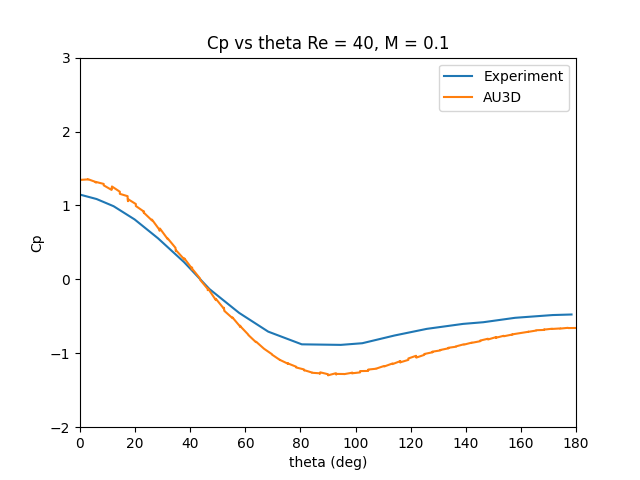

In [ ]:
# Plotting
plt.clf()

# imported experimental data
import pandas as pd
import matplotlib.pyplot as plt

cp_re40 = pd.read_csv("../../data/Re40/CpVsTheta_Re40.csv") 

# plot experimental data
plt.plot(cp_re40["x"], cp_re40[" y"], label = "Experiment")

# plot CFD surface data
idx = np.argsort(theta)
theta_sorted = np.array(theta)[idx]
pressure_coef_sorted = np.array(pressure_coef)[idx]

plt.plot(theta_sorted , pressure_coef_sorted, label = "AU3D")
plt.title("Cp vs theta Re = 40, M = 0.1")
plt.xlabel("theta (deg)")
plt.ylabel("Cp")
plt.legend()
plt.ylim(-2,3)
plt.xlim(0,180)